In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import pygtc

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [38]:
satgen_fid = pd.read_csv("../../data/summary_tabs/SatGen_fiducial.csv")
satgen_nocut = pd.read_csv("../../data/summary_tabs/SatGen_fiducial_nocut.csv")
satgen_Rcut = pd.read_csv("../../data/summary_tabs/SatGen_fiducial_Rcut.csv")

bolshoi = pd.read_csv("../../data/summary_tabs/BolshoiP.csv")
smdpl = pd.read_csv("../../data/summary_tabs/VSMDPL.csv")

bolshoi.replace([np.inf, -np.inf], 0.0, inplace=True)

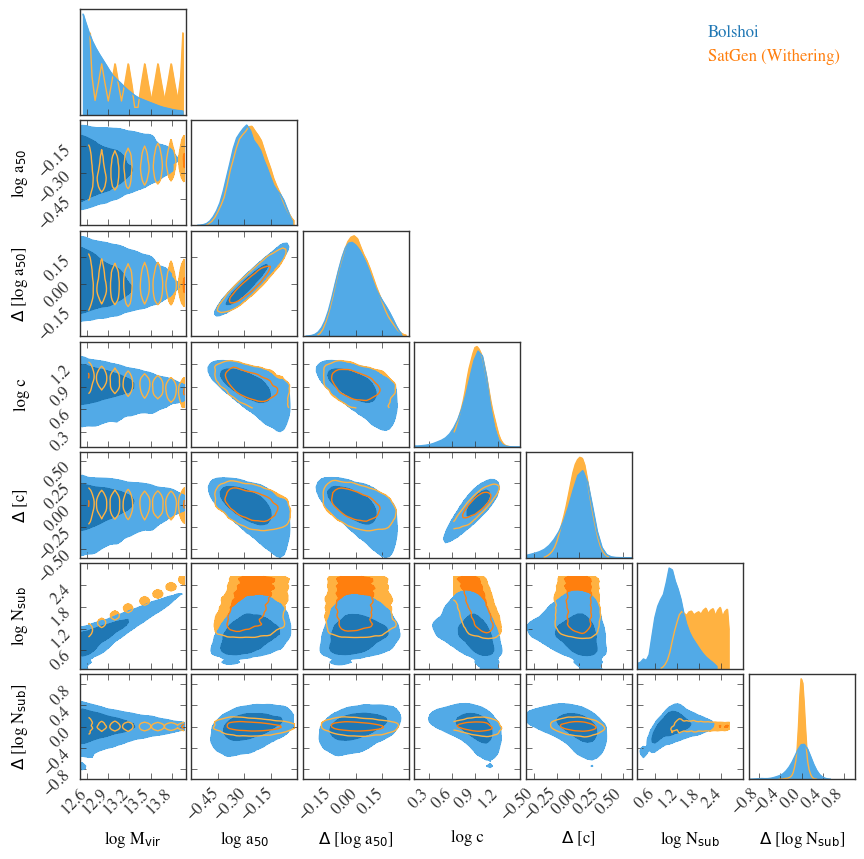

In [5]:
names = ['log M$_{\\rm vir}$',
         'log a$_{50}$',
         '$\\Delta$ [log a$_{50}$]',
         'log c',
         '$\\Delta$ [c]',
         'log N$_{\\rm sub}$',
         '$\\Delta$ [log N$_{\\rm sub}$]']

paramRanges = [
    [12.5, 14.0],   # log Mvir
    [-0.6, 0.0],    # log a50
    [-0.3, 0.3],    # Δ log a50
    [0.1, 1.5],     # log c
    [-0.6, 0.6],    # Δ c
    [0.1, 3.0],     # log Nsub
    [-1.0, 1.0]]     # Δ log Nsub

chain_labels = ["Bolshoi", "SatGen (Withering)"]
 
corner_comp = pygtc.plotGTC(
    chains=[bolshoi, satgen_nocut],
    paramNames=names,
    chainLabels=chain_labels,
    paramRanges=paramRanges,
    figureSize=10,
    customTickFont={'family':'Times', 'size':12},
    customLegendFont={'family':'Times', 'size':12},
    customLabelFont={'family':'Times', 'size':12},
    mathTextFontSet=None,
    panelSpacing='loose',
    colorsOrder=["blues", "oranges"] 
)

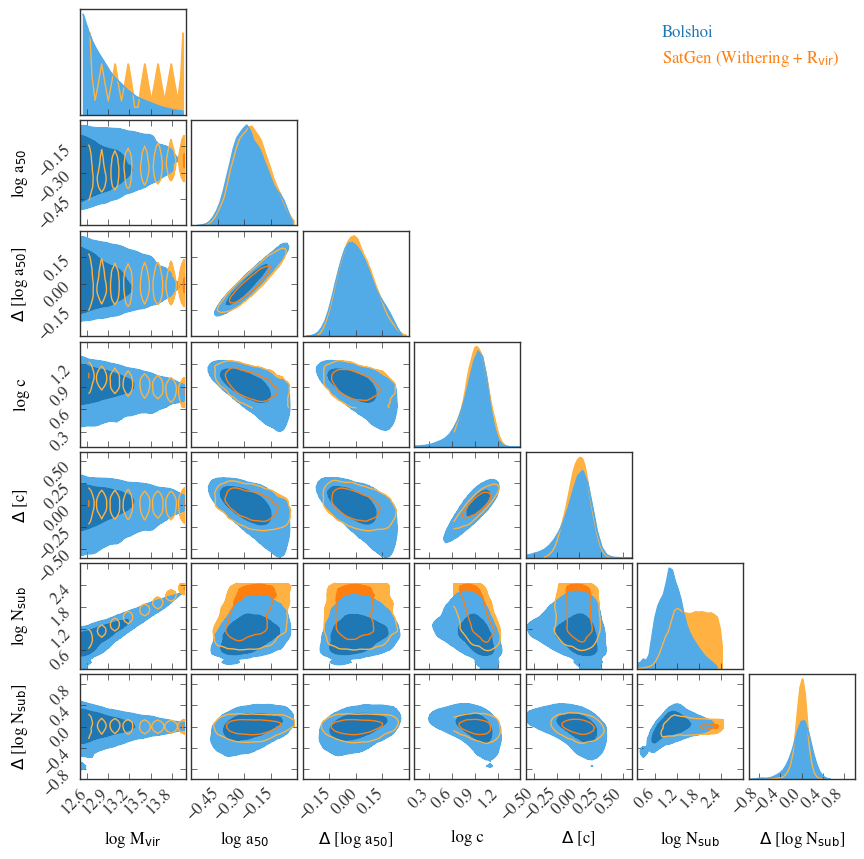

In [6]:
chain_labels = ["Bolshoi", "SatGen (Withering + R$_{\\rm vir}$)"]
 
corner_comp = pygtc.plotGTC(
    chains=[bolshoi, satgen_Rcut],
    paramNames=names,
    chainLabels=chain_labels,
    paramRanges=paramRanges,
    figureSize=10,
    customTickFont={'family':'Times', 'size':12},
    customLegendFont={'family':'Times', 'size':12},
    customLabelFont={'family':'Times', 'size':12},
    mathTextFontSet=None,
    panelSpacing='loose',
    colorsOrder=["blues", "oranges"] 
)

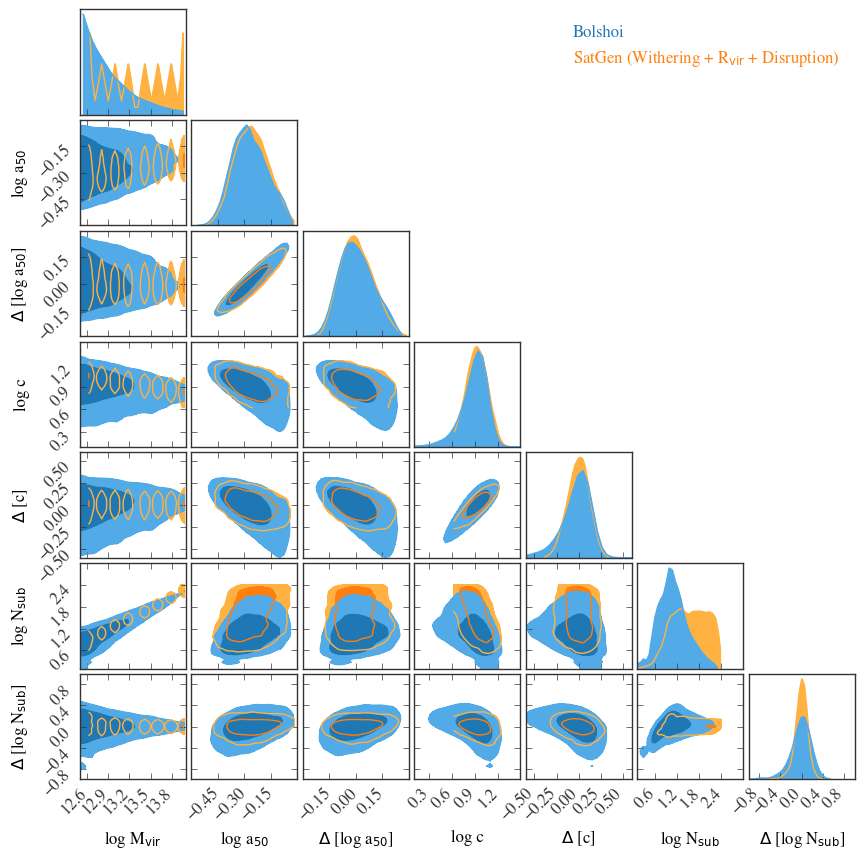

In [7]:
chain_labels = ["Bolshoi", "SatGen (Withering + R$_{\\rm vir}$ + Disruption)"]
 
corner_comp = pygtc.plotGTC(
    chains=[bolshoi, satgen_fid],
    paramNames=names,
    chainLabels=chain_labels,
    paramRanges=paramRanges,
    figureSize=10,
    customTickFont={'family':'Times', 'size':12},
    customLegendFont={'family':'Times', 'size':12},
    customLabelFont={'family':'Times', 'size':12},
    mathTextFontSet=None,
    panelSpacing='loose',
    colorsOrder=["blues", "oranges"] 
)

In [73]:
def make_binned_histograms(datasets, key):

    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.stats import ks_2samp

    lgM_min = [12.5, 12.7, 12.9, 13.1, 13.3, 13.5, 13.7, 13.9]
    lgM_max = [12.7, 12.9, 13.1, 13.3, 13.5, 13.7, 13.9, 14.1]

    n_bins = len(lgM_min)

    fig, ax = plt.subplots(1, n_bins, figsize=(22, 4), sharey=True, sharex=True)

    # Column titles
    for i in range(n_bins):
        label = rf"$10^{{{lgM_min[i]:.1f}}} < M_{{\rm h}} \leq 10^{{{lgM_max[i]:.1f}}}$"
        ax[i].set_title(label)

    # Store subsamples for KS test
    binned_values = [[] for _ in range(n_bins)]

    # Plot KDEs
    for k, dataset in enumerate(datasets):

        for i in range(n_bins):

            subsample = (
                (dataset["logMvir"] > lgM_min[i]) &
                (dataset["logMvir"] <= lgM_max[i])
            )

            vals = dataset[key][subsample]
            vals = vals[np.isfinite(vals)]

            sns.kdeplot(vals, ax=ax[i])

            binned_values[i].append(vals)

    # Compute KS test per bin
    for i in range(n_bins):

        if len(binned_values[i]) == 2:

            x = binned_values[i][0]
            y = binned_values[i][1]

            if len(x) > 5 and len(y) > 5:

                ks, p = ks_2samp(x, y)

                ax[i].text(
                    0.05, 0.95,
                    rf"$D={ks:.2f}$"+"\n"+rf"$p={p:.4f}$",
                    color="red" if p < 0.05 else "grey",
                    transform=ax[i].transAxes,
                    fontsize=10,
                    verticalalignment='top'
                )
    plt.show()

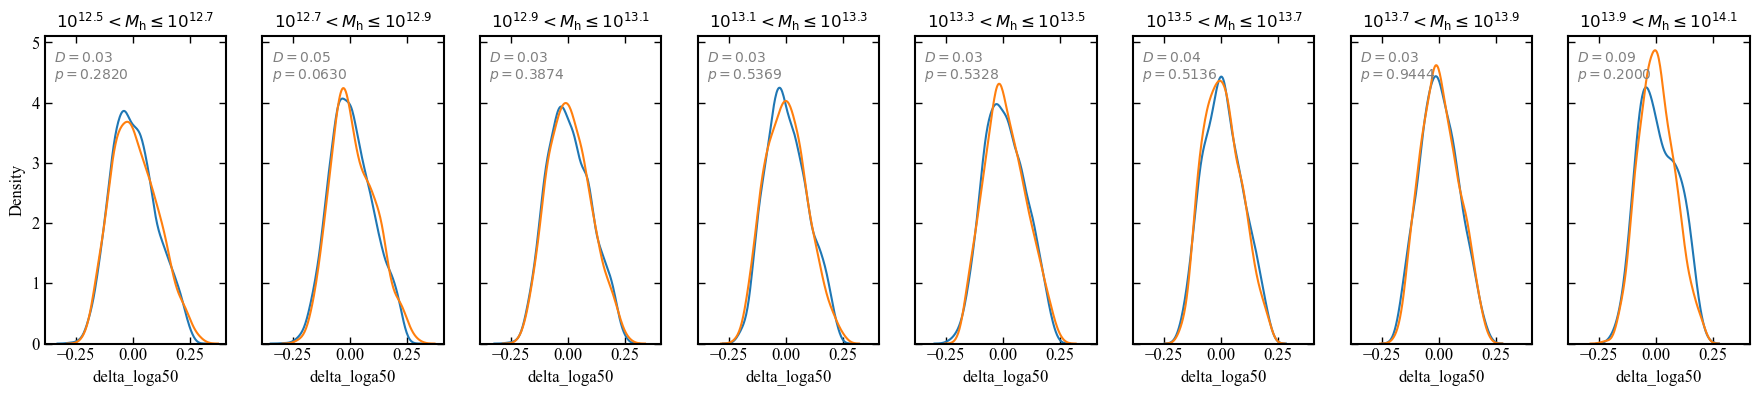

In [81]:
make_binned_histograms([bolshoi, satgen_fid], "delta_loga50")

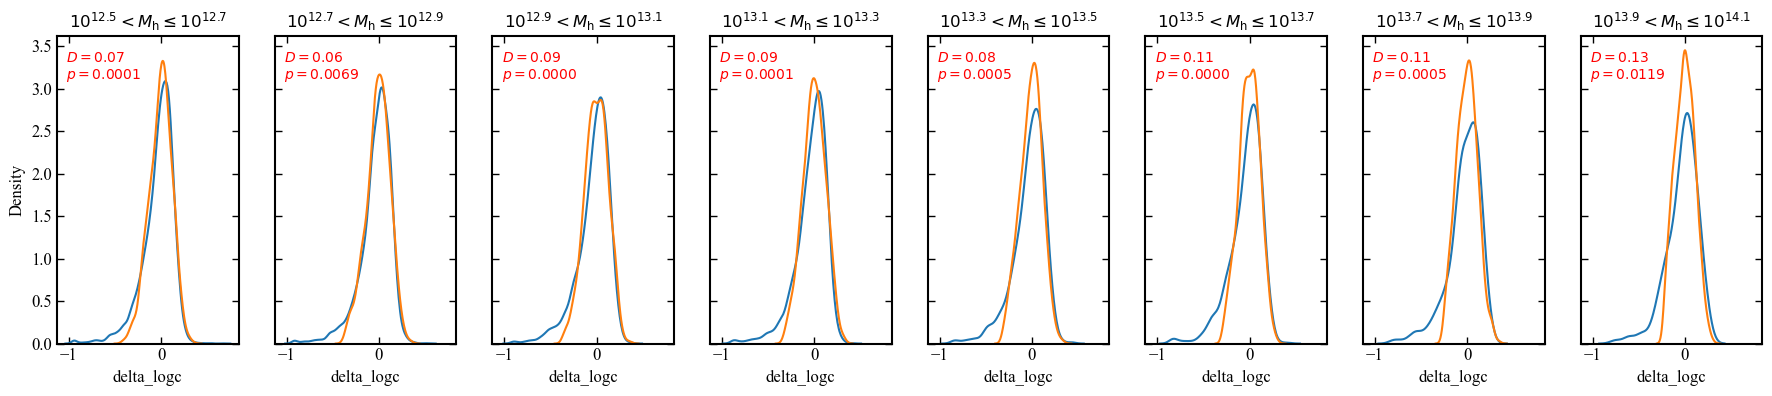

In [82]:
make_binned_histograms([bolshoi, satgen_fid], "delta_logc")

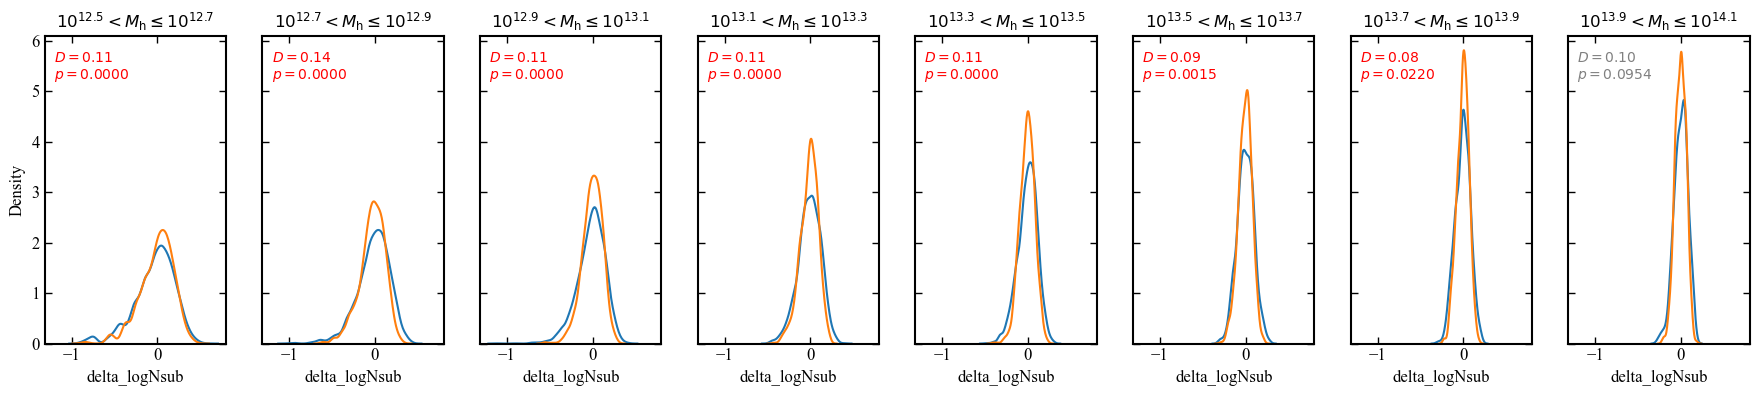

In [83]:
make_binned_histograms([bolshoi, satgen_fid], "delta_logNsub")